## Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [7]:
# Load dataset from Kaggle
df = pd.read_csv("../data/commerce.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Data Cleaning

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [9]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


In [10]:
# Data Cleaning
data_without_customer = df['CustomerID'].isnull().sum()
print(f"Data without CustomerID: {data_without_customer}")

negative_quantity = (df['Quantity'] < 0).sum()
print(f"Data with negative Quantity: {negative_quantity}")

negative_price = (df['UnitPrice'] < 0).sum()
print(f"Data with negative UnitPrice: {negative_price}")

# Drop transactions without CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# Drop transactions with negative Quantity or UnitPrice
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

print(f"Data after cleaning: {len(df_clean)}")
print(f"Percentage of data removed: {((len(df) - len(df_clean)) / len(df)) * 100:.2f}%")

Data without CustomerID: 135080
Data with negative Quantity: 10624
Data with negative UnitPrice: 2
Data after cleaning: 397884
Percentage of data removed: 26.58%


In [11]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## Building RFM Table

In [12]:
# Feature Engineering for RFM Table

# Create TotalAmount column as Quantity * UnitPrice
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Determine the last date in the dataset for Recency calculation
last_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1) # Adding 1 day to ensure all transactions are counted
print(f"Last date in the dataset: {last_date}")

# Calculate RFM values for each CustomerID
rfm = df_clean.groupby('CustomerID').agg({ 
    # Recency: Difference in days between last_date and the most recent InvoiceDate for each customer
    'InvoiceDate': lambda x: (last_date - x.max()).days,
    
    # Frequency: Counting the number of unique InvoiceNo for each customer
    'InvoiceNo': 'nunique',
    
    # Monetary: Summing up the TotalAmount column (sum)
    'TotalAmount': 'sum'
})

# Renaming columns to Recency, Frequency, and Monetary
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

rfm

Last date in the dataset: 2011-12-10 12:50:00


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [13]:
# Checking the distribution of RFM values
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


## Data Transformation

In [14]:
# Remove Skewness and Outliers with Log Transformation and StandardScaler
# np.log1p is used to handle zero values in the data, it applies log(1 + x) to each element in the RFM DataFrame and helps reduce skewness and mitigate the impact of outliers.
rfm_log = np.log1p(rfm)

# Standardize the log-transformed RFM values using StandardScaler, which makes it suitable for clustering algorithms like K-Means.
scaler = StandardScaler()
scaler.fit(rfm_log)

# Transform the log-transformed data into a scaled array
rfm_scaled_array = scaler.transform(rfm_log)

# Return the scaled array to a Pandas DataFrame for easier interpretation
rfm_scaled = pd.DataFrame(rfm_scaled_array, index=rfm.index, columns=rfm.columns)

# Checking the results of the preprocessed data for Machine Learning
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.706225
12347.0,-2.038734,1.074425,1.411843
12348.0,0.373104,0.386304,0.716489
12349.0,-0.623086,-0.955214,0.698739
12350.0,1.424558,-0.955214,-0.618962


## RFM Clustering

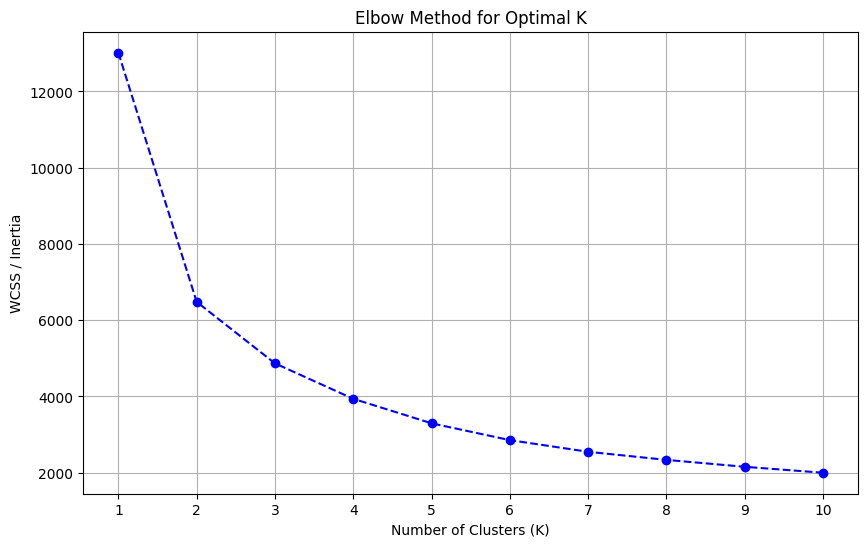

In [15]:
# Initializing an empty list to store WCSS values for each K
wcss = []

# Iterating over a range of K values (1 to 10) to fit KMeans and calculate WCSS for each K
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method graph to visualize WCSS values for different K and identify the optimal number of clusters
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Although K = 2 yields the highest drop in inertia, it is commercially impractical as it splits the customer base too broadly into just two extreme groups, which fails to provide actionable insights for targeted marketing. Therefore, K = 3 is selected as the optimal sweet spot. This successfully balancing mathematical variance reduction with business utility to group the audience into three highly distinct segments.

In [16]:
# Initializing KMeans with the optimal number of clusters (K=3) based on the Elbow Method
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

# Model Training and labeling using the scaled RFM data
kmeans.fit(rfm_scaled)
rfm['Cluster'] = kmeans.labels_

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,2
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,1


In [17]:
# Analyzing the profile of each cluster
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Total_Customers'})

cluster_analysis

,Recency,Frequency,Monetary,Total_Customers
Cluster,,,,
0,17.063636,13.338961,7905.440519,770
1,167.361111,1.352030,362.537613,1872
2,44.212264,3.378538,1265.063852,1696


Based on the aggregated RFM profiles, the customer base has been successfully segmented into three distinct lifecycles:

1. **Cluster 0: Champions (High-Value Customers)**
   * **Profile:** Exceptionally low Recency (~17 days), highest Frequency (~13 transactions), and a massive Monetary contribution (~$7905 per customer).
   * **Strategy:** Most valuable assets (770 VIPs). Should focus on premium loyalty rewards, exclusive early product access, and personalized VIP treatment to maximize retention.

2. **Cluster 2: Potential Loyalists (Mid-Value Core)**
   * **Profile:** Moderate Recency (~44 days), steady Frequency (~3.4 transactions), and healthy spend levels (~$1265).
   * **Strategy:** The backbone of our daily revenue (1696 customers). Drive them toward becoming Champions by cross-selling new product categories, offering product bundles, and utilizing milestone-based rewards.

3. **Cluster 1: At-Risk / Hibernating (Low-Value Mass)**
   * **Profile:** Severe lack of Recency (~167 days), very rare transactions (~1.3 times), and low overall spending (~$362).
   * **Strategy:** This represents our largest group (1872 customers) and are on the verge of churning. Offer automated win-back marketing campaigns with limited-time discounts to re-ignite their interest before they fully disconnect.

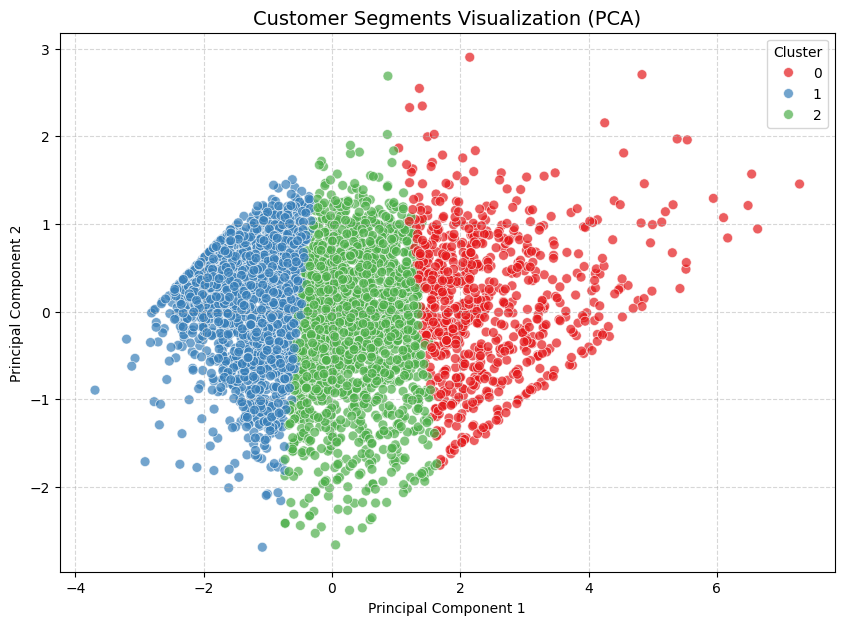

Loadings of RFM features on PC1 and PC2:
                PC1       PC2
Recency   -0.512079  0.849645
Frequency  0.617843  0.262445
Monetary   0.596695  0.457413


In [22]:
# Reducing dimensionality to 2D using PCA for visualization
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Create a DataFrame for PCA results and include the cluster labels for visualization
df_pca = pd.DataFrame(data=rfm_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = rfm.reset_index()['Cluster']

# Scatter plot to visualize the clusters in 2D space defined by the first two principal components (PC1 and PC2)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    data=df_pca, 
    palette='Set1',
    alpha=0.7, 
    s=50
)

plt.title('Customer Segments Visualization (PCA)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Loadings of the original RFM features on the principal components to understand which features contribute most to PC1 and PC2
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=rfm.columns[:3])
print("Loadings of RFM features on PC1 and PC2:")
print(loadings)

**Principal Component Analysis (PCA)** was applied to project the data into a 2-dimensional plane for optimal visualization without sacrificing critical variance.

Understanding the Axes:

Principal Component 1 (X Axis): This axis is heavily and positively driven by Frequency (+0.617) and Monetary (+0.596), while inversely driven by Recency (-0.512). Therefore, moving to the right along the X-axis mathematically signifies an increase in customer lifetime transaction loyalty and economic value (lower recency days, higher order counts, and larger spend amounts).

Principal Component 2 (Y Axis): This axis is predominantly affected by Recency (+0.849). It serves as a metric that captures the variance in when a customer last interacted with the platform, capturing the residual behavioral detail that PC1 alone cannot explain.